## 1. 全体のデータをTrain / Testに分割する

### **1) Xとy**

機械学習では、データを大きく入力データ（X）と正解データ（y）に分ける。

- `X（Feature）`：モデルに与える入力データ
- `y（Target）`：Xをもとにモデルが予測する正解データ

例）学生データを利用して合否を予測する場合

- `X` = 勉強時間、出席率 → 入力データ
- `y` = 合否 → 正解データ

<br>

### **2) データの分割**

全データを使って学習と評価を行うと、モデルの学習に使用したデータを再び評価にも使用することになり、モデルが未知のデータに対してどの程度予測できるかを正しく評価できない。

そのため、データを`訓練データ`と`テストデータ`に分割する。

<div style="font-family:'Malgun Gothic'; color:black; width:100%;">

<div style="background-color:#f4f5f5; padding:7px 14px;">
全体データ
</div>

<div style="background-color:#eaecee; padding:7px 14px;">
↓
</div>

<div style="background-color:#f4f5f5; padding:7px 14px;">
データを分割
</div>

<div style="background-color:#eaecee; padding:7px 14px;">
├─ Train set&nbsp;&nbsp;<span style="color:#ff7a00;">80%</span> → モデルの学習
</div>

<div style="background-color:#f4f5f5; padding:7px 14px;">
└─ Test set&nbsp;&nbsp;<span style="color:#ff7a00;">20%</span> → 最終評価
</div>

</div>

<br>

`X_train`、`y_train`を使ってモデルを学習し、`X_test`をモデルに入力して得られた予測結果と`y_test`を比較することで、モデルの性能（正解率）を評価する。

<div style="font-family:Consolas,'Yu Gothic',monospace; color:#111; width:100%;">

<div style="background:#f4f5f5; padding:7px 20px;">
<span style="color:#ff7a00;">X</span> → 入力 <span style="color:#ff4d4f;">変数</span>（Feature）
</div>

<div style="background:#f4f5f5; padding:7px 20px;">
<span style="color:#ff7a00;">y</span> → 正解 <span style="color:#ff4d4f;">変数</span>（Target）
</div>

<div style="background:#f4f5f5; height:18px;"></div>

<div style="background:#e6e8ea; padding:7px 20px;">
全体データ
</div>

<div style="background:#f4f5f5; padding:5px 58px;">
↓
</div>

<div style="background:#e6e8ea; padding:7px 20px;">
<span style="color:#ff4d6d;">train_test_split()</span>
</div>

<div style="background:#f4f5f5; padding:5px 58px;">
↓
</div>

<div style="background:#e6e8ea; padding:4px 20px; white-space:pre;">┌─────────────────┬─────────────────┐</div>

<div style="background:#f4f5f5; padding:4px 20px; white-space:pre;">│ 訓練データ <span style="color:#ff7a00;">80%</span>  │ テストデータ <span style="color:#ff7a00;">20%</span>  │</div>

<div style="background:#e6e8ea; padding:4px 20px; white-space:pre;">├─────────────────┼─────────────────┤</div>

<div style="background:#f4f5f5; padding:4px 20px; white-space:pre;">│ X_train         │ X_test          │</div>

<div style="background:#e6e8ea; padding:4px 20px; white-space:pre;">│ y_train         │ y_test          │</div>

<div style="background:#f4f5f5; padding:4px 20px; white-space:pre;">└─────────────────┴─────────────────┘</div>

<div style="background:#e6e8ea; padding:5px 20px; white-space:pre;">       ↓                 ↓</div>

<div style="background:#f4f5f5; padding:7px 20px; white-space:pre;">   モデル学習          モデル評価</div>

</div>

<br>

### 3) scikit-learnライブラリを使用してデータを分割

`fish`データセットを`X_train`、`X_test`、`y_train`、`y_test`に分割し、KNNアルゴリズムによる予測に使用する。

https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv

- `X_train`：訓練用の入力データ
- `X_test`：テスト用の入力データ
- `y_train`：訓練用の正解データ
- `y_test`：テスト用の正解データ

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,      # 全体データを訓練用70%・テスト用30%に分割
    random_state=42,    # 毎回同じ分割結果になるように乱数を固定
    stratify=y          # 元データのクラス比率を訓練・テストデータでも維持
)

# test_size=0.3
# → 訓練データ：約70%
# → テストデータ：約30%

# stratify=y
# → Bream / Smelt の割合をできるだけ維持して分割
# 例）元データが Bream 70%、Smelt 30% の場合
#
# 訓練データ：約 Bream 70%、Smelt 30%
# テストデータ：約 Bream 70%、Smelt 30%

<br>

<img src="../images/image-70_1.png" width="1000">

<br>

### ■ BreamとSmeltのデータを訓練用・テスト用に分割し、標準化した後、KNNモデルを学習・予測して正解率を評価する。

<br>

<table>
<tr>
<td align="center">
<img src="../images/image-70_2.jpg" width="320"><br>
<b>Bream（ブリーム／コイ科の魚）</b>
</td>

<td align="center">
<img src="../images/image-70_3.jpg" width="300"><br>
<b>Smelt（スメルト／キュウリウオ科の魚）</b>
</td>
</tr>
</table>

<br>

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import pandas as pd

<br>

#### 1. データの読み込み

In [2]:
fish = pd.read_csv(
    "https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv"
)

<br>

#### 2. BreamとSmeltのみを選択

In [3]:
fish = fish[fish["Species"].isin(["Bream", "Smelt"])]

<br>

#### 3. 入力データ（X）
-> LengthとWeightを使用

In [4]:
X = fish[["Length", "Weight"]]

<br>

#### 4. ターゲットデータ（y）
-> Bream = 1、Smelt = 0

In [5]:
y = fish["Species"].map({
    "Bream": 1,
    "Smelt": 0
})

<br>

#### 5. 訓練データとテストデータに8:2で分割

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<br>

#### 6. データの確認
-> スケーリング前のデータを散布図で可視化

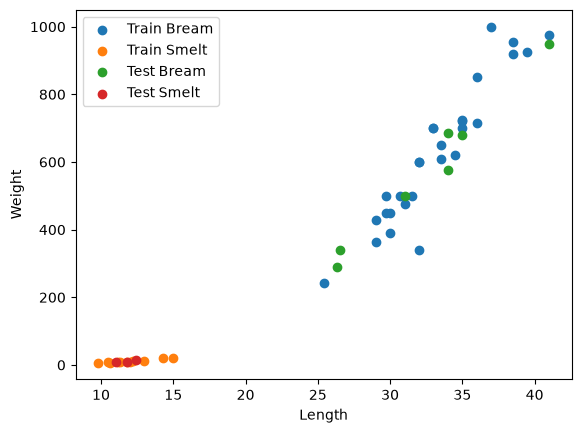

In [7]:
plt.figure()

# 訓練データ - Bream
plt.scatter(
    X_train[y_train == 1]["Length"],
    X_train[y_train == 1]["Weight"],
    label="Train Bream"
)

# 訓練データ - Smelt
plt.scatter(
    X_train[y_train == 0]["Length"],
    X_train[y_train == 0]["Weight"],
    label="Train Smelt"
)

# テストデータ - Bream
plt.scatter(
    X_test[y_test == 1]["Length"],
    X_test[y_test == 1]["Weight"],
    label="Test Bream"
)

# テストデータ - Smelt
plt.scatter(
    X_test[y_test == 0]["Length"],
    X_test[y_test == 0]["Weight"],
    label="Test Smelt"
)

plt.xlabel("Length")
plt.ylabel("Weight")
plt.legend()
plt.show()

<br>

#### 7. 標準化

In [8]:
scaler = StandardScaler()

# 訓練データから平均・標準偏差を学習し、その基準で変換
X_train_scaled = scaler.fit_transform(X_train)

# 新たに学習せず、訓練データから学習した基準でテストデータを変換
# scalerはすでに上のfit_transform()で学習済み
# fit()またはfit_transform()の前にtransform()を呼び出すとエラーが発生
# NotFittedError: This StandardScaler instance is not fitted yet

X_test_scaled = scaler.transform(X_test)

<br>

#### 8. スケーリング結果を確認

In [9]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())
display(X_test_scaled.head())

,Length,Weight
150,-1.583000,-1.362316
0,-0.183496,-0.649455
152,-1.533372,-1.358650
154,-1.493670,-1.351622
31,1.116753,1.529158


,Length,Weight
1,-0.094166,-0.502788
151,-1.533372,-1.358344
21,0.670103,0.704157
11,0.372336,0.138879
155,-1.473819,-1.347955


<br>

#### 9. スケーリング後のデータを散布図で可視化

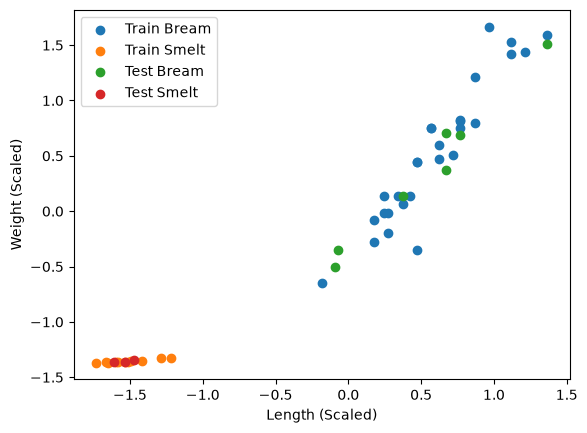

In [10]:
plt.figure()

# 訓練データ - Bream
plt.scatter(
    X_train_scaled[y_train == 1]["Length"],
    X_train_scaled[y_train == 1]["Weight"],
    label="Train Bream"
)

# 訓練データ - Smelt
plt.scatter(
    X_train_scaled[y_train == 0]["Length"],
    X_train_scaled[y_train == 0]["Weight"],
    label="Train Smelt"
)

# テストデータ - Bream
plt.scatter(
    X_test_scaled[y_test == 1]["Length"],
    X_test_scaled[y_test == 1]["Weight"],
    label="Test Bream"
)

# テストデータ - Smelt
plt.scatter(
    X_test_scaled[y_test == 0]["Length"],
    X_test_scaled[y_test == 0]["Weight"],
    label="Test Smelt"
)

plt.xlabel("Length (Scaled)")
plt.ylabel("Weight (Scaled)")
plt.legend()
plt.show()

<br>

#### 10. KNNモデルを作成

In [11]:
kn = KNeighborsClassifier(
    n_neighbors=5
)

<br>

#### 11. スケーリング済みの訓練データでモデルを学習

In [12]:
kn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


<br>

#### 12. スケーリング済みのテストデータで予測

In [13]:
y_pred = kn.predict(X_test_scaled)

<br>

#### 13. モデルを評価

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("予測値:", y_pred)
print("実際の値:", y_test.values)
print("テスト正解率:", accuracy)

予測値: [1 0 1 1 0 1 1 1 0 1]
実際の値: [1 0 1 1 0 1 1 1 0 1]
テスト正解率: 1.0


<br>

## 2. データ分割の実習

### 1) fish.csvデータセット

`Perch`と`Pike`のみを選択し、`Length`と`Height`を入力変数として使用する。

<br>

<table>
<tr>
<td align="center">
<img src="../images/image-70_4.jpg" width="320"><br>
<b>Perch（パーチ／スズキ目パーチ科の魚）</b>
</td>

<td align="center">
<img src="../images/image-70_5.jpg" width="320"><br>
<b>Pike（カワカマス／カワカマス科の魚）</b>
</td>
</tr>
</table>

<br>

In [16]:
# データの読み込み
fish = pd.read_csv(
    "https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv"
)

# PerchとPikeのみを選択
fish2 = fish[fish["Species"].isin(["Perch", "Pike"])]

# 入力データ
X = fish2[["Length", "Height"]]

# 正解（ターゲット）データ
y = fish2["Species"]

`X`には魚の`Length・Height`を、`y`には魚の種類（`Perch・Pike`）を設定する。

<br>

In [18]:
X.head()

,Length,Height
72,8.4,2.1120
73,13.7,3.5280
74,15.0,3.8240
75,16.2,4.5924
76,17.4,4.5880


<br>

In [19]:
y.unique()

<StringArray>
['Perch', 'Pike']
Length: 2, dtype: str

<br>

### 2) penguins.csvデータセット

欠損値を削除した後、`Adelie`と`Gentoo`のみを選択して入力データとターゲットデータを作成する。

<br>

<br>

<table>
<tr>
<td align="center">
<img src="../images/image-70_6.jpg" style="height:240px; width:auto;"><br>
<b>Adelie（アデリーペンギン）</b>
</td>

<td align="center">
<img src="../images/image-70_7.jpg" style="height:240px; width:auto;"><br>
<b>Gentoo（ジェンツーペンギン）</b>
</td>
</tr>
</table>

In [20]:
penguins = pd.read_csv(
    "https://raw.githubusercontent.com/cran/palmerpenguins/master/inst/extdata/penguins.csv"
)

# 欠損値を削除
penguins = penguins.dropna()

# AdelieとGentooのみを選択
penguins = penguins[
    penguins["species"].isin(["Adelie", "Gentoo"])
]

# 入力データ
X = penguins[["bill_length_mm", "body_mass_g"]]

# ターゲットデータ
y = penguins["species"]

`X`にはペンギンの`bill_length_mm・body_mass_g`を、`y`には種類（`Adelie・Gentoo`）を設定する。

<br>

In [22]:
X.head()

,bill_length_mm,body_mass_g
0,39.1,3750.0
1,39.5,3800.0
2,40.3,3250.0
4,36.7,3450.0
5,39.3,3650.0


<br>

In [31]:
(y.unique())

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

<br>

### 3) iris.csvデータセット

ターゲット`y`に3つのクラスが存在する場合の例。

<div align="center">

<img src="../images/image-70_8.jpg" width="300"><br><br>

<table>
<tr>
<td align="center" style="padding-right:40px;">
<b>sepal_length</b><br>
がく片の長さ
</td>

<td align="center">
<b>petal_length</b><br>
花弁の長さ
</td>
</tr>
</table>

</div>

<br>

In [25]:
# yのクラスが3つの場合

iris = pd.read_csv(
    "https://raw.githubusercontent.com/duchesnay/pystatsml/master/datasets/iris.csv"
)

# 入力データ
X = iris[["sepal_length", "petal_length"]]

# ターゲットデータ
y = iris["species"]

<br>

`X`には`sepal_length・petal_length`を使用し、`y`には3種類のアヤメのクラスを設定する。

<Br>

In [26]:
X.head()

,sepal_length,petal_length
0,5.1,1.4
1,4.9,1.4
2,4.7,1.3
3,4.6,1.5
4,5.0,1.4


<br>

In [27]:
y.unique()

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str